In [3]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent))

from gamma.artifacts import ArtifactStore
from gamma.types import CalibrationSpec
from gamma.calibration import calibrate_experiment

In [4]:
store = ArtifactStore("../artifacts")

In [5]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [6]:
###Initialize known energy peaks [in keV]
AC_Fr_Peak = 218.0 
AC_Bi_Peak = 440.45
CE_511 = 510.99895069
CE_1022 = 1021.99790138

# Load Experiments
### (Load Aggregated and Subtracted Experiments from `01_ingest.ipynb`)

In [7]:
# Anil Ce
# BASE_EXPID = "ANIL_CE_SD"          # change per run, or parameterize later
# AGG_EXPID  = BASE_EXPID + "__agg"  # your convention

anil_ce_exp_id = "ANIL_CE_SD__agg__bkgsub" #if store.has_experiment(AGG_EXPID) else BASE_EXPID
anil_ce_exp = store.load_experiment(anil_ce_exp_id)

print("Using experiment:", anil_ce_exp.experiment_id)
print("counts shape:", anil_ce_exp.counts.shape)
print("n labels:", len(anil_ce_exp.labels))

# Wenjo Ce
wenjo_ce_exp_id = "WENJO_CE_SD__agg__bkgsub__nobkgrows"
wenjo_ce_exp = store.load_experiment(wenjo_ce_exp_id)

print("Using experiment:", wenjo_ce_exp.experiment_id)
print("counts shape:", wenjo_ce_exp.counts.shape)
print("n labels:", len(wenjo_ce_exp.labels))

# Anil Ac
anil_ac_exp_id =  "ANIL_AC_SD__agg__bkgsub"
anil_ac_exp = store.load_experiment(anil_ac_exp_id)

print("Using experiment:", anil_ac_exp.experiment_id)
print("counts shape:", anil_ac_exp.counts.shape)
print("n labels:", len(anil_ac_exp.labels))

# Anil Mix
anil_mix_exp_id =  "ANIL_MIX_SD__agg__bkgsub"
anil_mix_exp = store.load_experiment(anil_mix_exp_id)

print("Using experiment:", anil_mix_exp.experiment_id)
print("counts shape:", anil_mix_exp.counts.shape)
print("n labels:", len(anil_mix_exp.labels))

Using experiment: ANIL_CE_SD__agg__bkgsub
counts shape: (10, 2048)
n labels: 10
Using experiment: WENJO_CE_SD__agg__bkgsub__nobkgrows
counts shape: (10, 2048)
n labels: 10
Using experiment: ANIL_AC_SD__agg__bkgsub
counts shape: (10, 2048)
n labels: 10
Using experiment: ANIL_MIX_SD__agg__bkgsub
counts shape: (8, 2048)
n labels: 8


# Initialize Calibration Parameters with `CalibrationSpec`

In [8]:
ce_spec = CalibrationSpec(
    method="peakfit_v1", #Just a label saving these specific calibration parameters
    params={
        "expected_energies": [CE_511, CE_1022],
        "kernel": (500, 50),
        "min_snr": 1.2,
        "xmin": 200,
        "livetime": 60.0,
        "tolerance": 75,
        "method": "fit",
        "fit_order": 1,
        # "fallback_calibration": ...,
        # "force_calibration": ...,
        "debug": False,
    },
)

ac_spec = CalibrationSpec(
    method="peakfit_v1",   # or whatever you want to call this method
    params={
        "expected_energies": [AC_Fr_Peak, AC_Bi_Peak],
        "kernel": (500, 50),
        "min_snr": 1.2,
        "xmin": 200,
        "livetime": 60.0,
        "tolerance": 75,
        "method": "fit",
        "fit_order": 1,
        # "fallback_calibration": ...,
        # "force_calibration": ...,
        "debug": False,
    },
)

mix_spec = CalibrationSpec(
    method="peakfit_v1",   # or whatever you want to call this method
    params={
        "expected_energies": [AC_Fr_Peak, AC_Bi_Peak, CE_511, CE_1022],
        "kernel": (500, 50),
        "min_snr": 1.2,
        "xmin": 200,
        "livetime": 60.0,
        "tolerance": 75,
        "method": "fit",
        "fit_order": 1,
        # "fallback_calibration": ...,
        # "force_calibration": ...,
        "debug": False,
    },
)

In [9]:
# a stable, human-readable tag (keep it short) #IDEK if this is necessary...
ce_p = ce_spec.params
ce_spec_cal_tag = (
    f"{ce_spec.method}"
    f"_xmin{ce_p.get('xmin', 'na')}"
    f"_snr{ce_p.get('min_snr', 'na')}"
    f"_tol{ce_p.get('tolerance', 'na')}"
    f"_fit{ce_p.get('method', 'na')}"
    f"_ord{ce_p.get('fit_order', 'na')}"
)
print("Ce Calibration tag:", ce_spec_cal_tag)

ac_p = ac_spec.params
ac_spec_cal_tag = (
    f"{ac_spec.method}"
    f"_xmin{ac_p.get('xmin', 'na')}"
    f"_snr{ac_p.get('min_snr', 'na')}"
    f"_tol{ac_p.get('tolerance', 'na')}"
    f"_fit{ac_p.get('method', 'na')}"
    f"_ord{ac_p.get('fit_order', 'na')}"
)
print("Ac Calibration tag:", ac_spec_cal_tag)

mix_p = mix_spec.params
mix_spec_cal_tag = (
    f"{ac_spec.method}"
    f"_xmin{mix_p.get('xmin', 'na')}"
    f"_snr{mix_p.get('min_snr', 'na')}"
    f"_tol{mix_p.get('tolerance', 'na')}"
    f"_fit{mix_p.get('method', 'na')}"
    f"_ord{mix_p.get('fit_order', 'na')}"
)
print("Mix Calibration tag:", mix_spec_cal_tag)

Ce Calibration tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1
Ac Calibration tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1
Mix Calibration tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1


# Apply Calibrations

In [10]:
anil_ce_cal = calibrate_experiment(anil_ce_exp, ce_spec, progress=True)
store.save_calibration(anil_ce_cal, calibration_spec=ce_spec, calibration_tag=ce_spec_cal_tag, prefer_lightweight=True)
print("Calibrated + saved.")

wenjo_ce_cal = calibrate_experiment(wenjo_ce_exp, ce_spec, progress=True)
store.save_calibration(wenjo_ce_cal, calibration_spec=ce_spec, calibration_tag=ce_spec_cal_tag, prefer_lightweight=True)
print("Calibrated + saved.")

anil_ac_cal = calibrate_experiment(anil_ac_exp, ac_spec, progress=True)
store.save_calibration(anil_ac_cal, calibration_spec=ac_spec, calibration_tag=ac_spec_cal_tag, prefer_lightweight=True)
print("Calibrated + saved.")

anil_mix_cal = calibrate_experiment(anil_mix_exp, mix_spec, progress=True)
store.save_calibration(anil_mix_cal, calibration_spec=mix_spec, calibration_tag=mix_spec_cal_tag, prefer_lightweight=True)
print("Calibrated + saved.")

[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 0/10 ...


C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\becquerel\core\calibration.py:153: CalibrationWarning: Function values are above the upper range (1000000.0)
  warnings.warn(msg, CalibrationWarning)


[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 1/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 2/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 3/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 4/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 5/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 6/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 7/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 8/10 ...
[calibrate_experiment] ANIL_CE_SD__agg__bkgsub: 9/10 ...
Calibrated + saved.
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 0/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 1/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 2/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 3/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 4/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 5/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobk

# Save Calibrations

In [11]:
store.save_calibration(
    anil_ce_cal,
    calibration_spec=ce_spec,
    calibration_tag=ce_spec_cal_tag,
    prefer_lightweight=True,
)
print("Saved calibration for:", anil_ce_cal.experiment_id, "tag:", ce_spec_cal_tag)

store.save_calibration(
    wenjo_ce_cal,
    calibration_spec=ce_spec,
    calibration_tag=ce_spec_cal_tag,
    prefer_lightweight=True,
)
print("Saved calibration for:", wenjo_ce_cal.experiment_id, "tag:", ce_spec_cal_tag)

store.save_calibration(
    anil_ac_cal,
    calibration_spec=ac_spec,
    calibration_tag=ac_spec_cal_tag,
    prefer_lightweight=True,
)
print("Saved calibration for:", anil_ac_cal.experiment_id, "tag:", ac_spec_cal_tag)

store.save_calibration(
    anil_mix_cal,
    calibration_spec=mix_spec,
    calibration_tag=mix_spec_cal_tag,
    prefer_lightweight=True,
)
print("Saved calibration for:", anil_mix_cal.experiment_id, "tag:", mix_spec_cal_tag)

Saved calibration for: ANIL_CE_SD__agg__bkgsub tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1
Saved calibration for: WENJO_CE_SD__agg__bkgsub__nobkgrows tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1
Saved calibration for: ANIL_AC_SD__agg__bkgsub tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1
Saved calibration for: ANIL_MIX_SD__agg__bkgsub tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1


# Visualize Calibrations

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


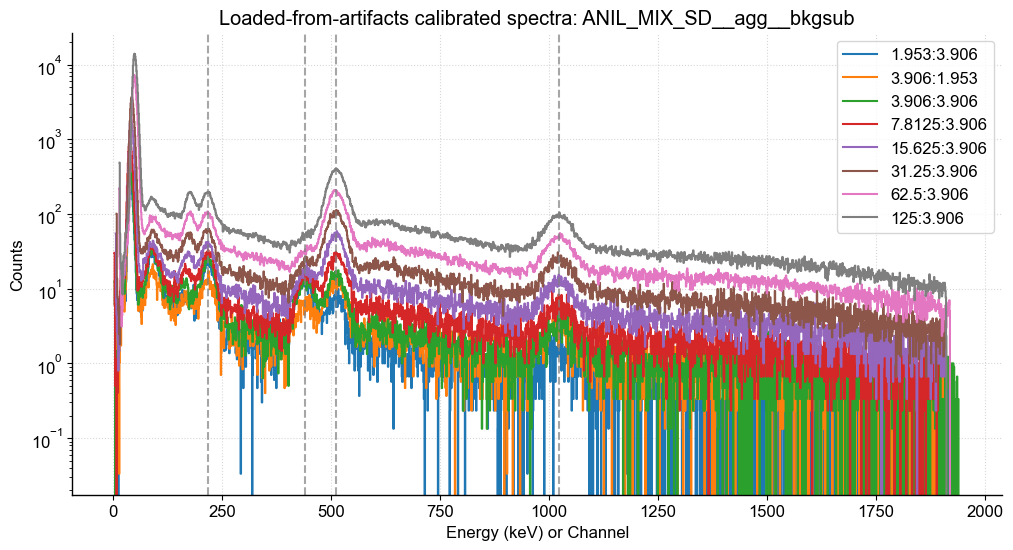

In [12]:
# Anil Mix

labels_to_plot = list(anil_mix_cal.calibrated.keys())[:]

for label in labels_to_plot:
    obj = anil_mix_cal.calibrated[label]
    # schema = obj.get("meta", {}).get("schema")

    # if schema != "bq_v1":
    #     raise RuntimeError(f"Need calibrated spectra (schema=bq_v1) for efficiency; got {schema!r}")

    x = obj.bin_centers_kev
    y = obj.counts_vals
    plt.step(x, y, where="mid", label=label)


plt.yscale("log")
plt.xlabel("Energy (keV) or Channel")
plt.ylabel("Counts")
plt.legend()
plt.axvline(AC_Fr_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(AC_Bi_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(CE_511, color='gray', ls='--', alpha=0.7)
plt.axvline(CE_1022, color='gray', ls='--', alpha=0.7)
plt.title(f"Loaded-from-artifacts calibrated spectra: {anil_mix_cal.experiment_id}")
plt.show()

In [16]:
import pandas as pd

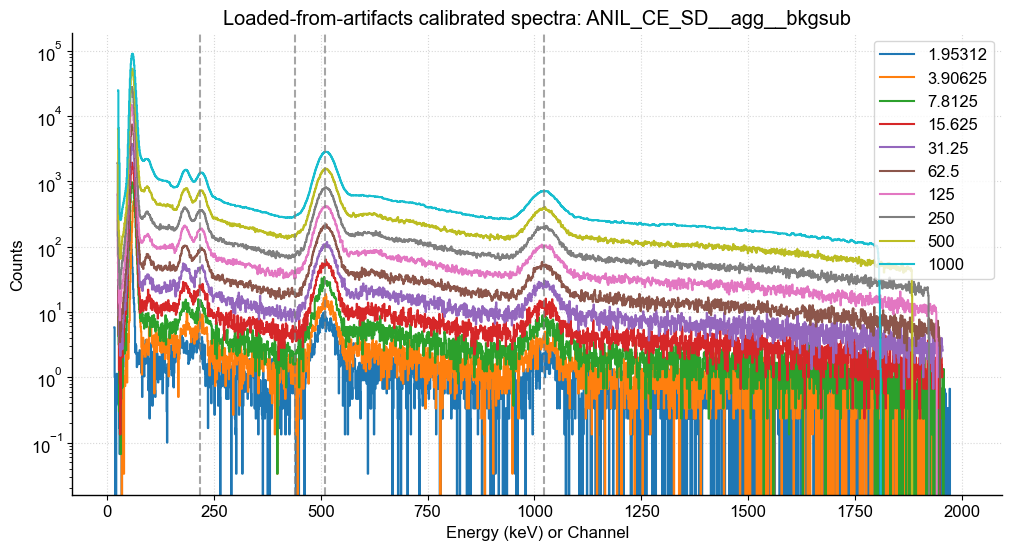

,Ce-134 activity,Integrated counts in 1022 ± 50 keV
0,1.95312,157.633333
1,3.90625,275.333333
2,7.8125,537.666667
3,15.625,1032.466667
4,31.25,2123.133333
5,62.5,4168.566667
6,125,8446.333333
7,250,16071.333333
8,500,30778.766667
9,1000,57576.900000


In [20]:
# Anil Ce

labels_to_plot = list(anil_ce_cal.calibrated.keys())[:]

data_dic = {'Ce-134 activity':[],'Integrated counts in 1022 ± 50 keV':[]}

for label in labels_to_plot:
    obj = anil_ce_cal.calibrated[label]
    # schema = obj.get("meta", {}).get("schema")

    # if schema != "bq_v1":
    #     raise RuntimeError(f"Need calibrated spectra (schema=bq_v1) for efficiency; got {schema!r}")

    x = obj.bin_centers_kev
    y = obj.counts_vals
    plt.step(x, y, where="mid", label=label)

    goods = (x > 972) * (x < 1072) # looking 50 channels above and below the 1022 keV peak
    window = obj.counts_vals[goods]
    integrated_window = sum(window)
    data_dic['Ce-134 activity'].append(label)
    data_dic['Integrated counts in 1022 ± 50 keV'].append(integrated_window)

plt.yscale("log")
plt.xlabel("Energy (keV) or Channel")
plt.ylabel("Counts")
plt.legend()
plt.axvline(AC_Fr_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(AC_Bi_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(CE_511, color='gray', ls='--', alpha=0.7)
plt.axvline(CE_1022, color='gray', ls='--', alpha=0.7)
plt.title(f"Loaded-from-artifacts calibrated spectra: {anil_ce_cal.experiment_id}")
plt.show()

data_df_ce = pd.DataFrame(data_dic)
display(data_df_ce)

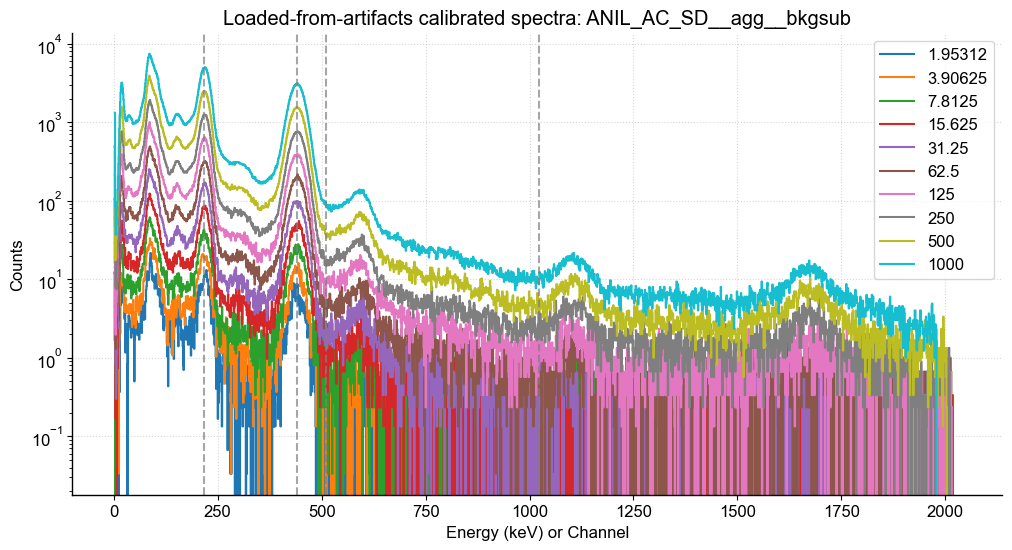

,Ac-225 activity,Integrated counts in 1022 ± 50 keV
0,1.95312,5.933333
1,3.90625,12.766667
2,7.8125,10.033333
3,15.625,18.133333
4,31.25,33.933333
5,62.5,65.633333
6,125,131.100000
7,250,262.766667
8,500,514.800000
9,1000,1103.933333


,Ce-134 activity,Integrated counts in 1022 ± 50 keV
0,1.95312,157.633333
1,3.90625,275.333333
2,7.8125,537.666667
3,15.625,1032.466667
4,31.25,2123.133333
5,62.5,4168.566667
6,125,8446.333333
7,250,16071.333333
8,500,30778.766667
9,1000,57576.900000


In [21]:
# Anil Ac

labels_to_plot = list(anil_ac_cal.calibrated.keys())[:]

data_dic = {'Ac-225 activity':[],'Integrated counts in 1022 ± 50 keV':[]}

for label in labels_to_plot:
    obj = anil_ac_cal.calibrated[label]
    # schema = obj.get("meta", {}).get("schema")

    # if schema != "bq_v1":
    #     raise RuntimeError(f"Need calibrated spectra (schema=bq_v1) for efficiency; got {schema!r}")

    x = obj.bin_centers_kev
    y = obj.counts_vals
    plt.step(x, y, where="mid", label=label)

    goods = (x > 972) * (x < 1072) # looking 50 channels above and below the 1022 keV peak
    window = obj.counts_vals[goods]
    integrated_window = sum(window)
    data_dic['Ac-225 activity'].append(label)
    data_dic['Integrated counts in 1022 ± 50 keV'].append(integrated_window)


plt.yscale("log")
plt.xlabel("Energy (keV) or Channel")
plt.ylabel("Counts")
plt.legend()
plt.axvline(AC_Fr_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(AC_Bi_Peak, color='gray', ls='--', alpha=0.7)
plt.axvline(CE_511, color='gray', ls='--', alpha=0.7)
plt.axvline(CE_1022, color='gray', ls='--', alpha=0.7)
plt.title(f"Loaded-from-artifacts calibrated spectra: {anil_ac_cal.experiment_id}")
plt.show()

data_df = pd.DataFrame(data_dic)
display(data_df)
display(data_df_ce)

In [ ]:
end

NameError: name 'end' is not defined

In [ ]:
# if store.has_calibration(exp.experiment_id, cal_tag):
#     print("Calibration already exists — loading.")
#     cal = store.load_calibration(exp.experiment_id, cal_tag)

# else:



[calibrate_experiment] ANIL_CE_SD__agg: 0/10 ...


C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\becquerel\core\calibration.py:153: CalibrationWarning: Function values are above the upper range (1000000.0)
  warnings.warn(msg, CalibrationWarning)


[calibrate_experiment] ANIL_CE_SD__agg: 1/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 2/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 3/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 4/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 5/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 6/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 7/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 8/10 ...
[calibrate_experiment] ANIL_CE_SD__agg: 9/10 ...
Calibrated + saved.


__CALIBRATING:__ Wenjo Ce Serial Dilution

Experimental ID: `WENJO_CE_SD__agg__bkgsub`

In [ ]:
exp_id_2 = "WENJO_CE_SD__agg__bkgsub__nobkgrows"
exp2 = store.load_experiment(exp_id_2)

print("Using experiment:", exp2.experiment_id)
print("counts shape:", exp2.counts.shape)
print("n labels:", len(exp2.labels))

Using experiment: WENJO_CE_SD__agg__bkgsub__nobkgrows
counts shape: (10, 2048)
n labels: 10


In [ ]:
print(type(exp2))
display(exp2)

<class 'gamma.types.Experiment'>


Experiment(experiment_id='WENJO_CE_SD__agg__bkgsub__nobkgrows', counts=array([[4.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.5000e+00, 2.0000e+00, 0.0000e+00, ..., 4.0000e-01, 0.0000e+00,
        0.0000e+00],
       [7.5000e+00, 1.0000e+00, 0.0000e+00, ..., 0.0000e+00, 5.0000e-01,
        0.0000e+00],
       ...,
       [1.8200e+02, 3.4500e+01, 1.2000e+01, ..., 1.9000e+00, 2.0000e+00,
        0.0000e+00],
       [3.9900e+02, 5.0500e+01, 2.2500e+01, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00],
       [1.0465e+03, 8.8000e+01, 5.4500e+01, ..., 0.0000e+00, 0.0000e+00,
        0.0000e+00]]), labels=['0.390625', '0.78125', '1.5625', '3.125', '6.25', '12.5', '25', '50', '100', '200'], weights=None, meta={'aggregation': {'ddof': 1, 'group_key': 'activity', 'n_reps': [10, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], 'uncertainty_kind': 'sd_between'}, 'background_subtraction': {'bkg_bank_size': None, 'bkg_livetime_s': None, 'clamp_nonnegative': True, 'emb

[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 0/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 1/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 2/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 3/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 4/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 5/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 6/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 7/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 8/10 ...
[calibrate_experiment] WENJO_CE_SD__agg__bkgsub__nobkgrows: 9/10 ...
Calibrated + saved.


In [ ]:
store.save_calibration(
    cal2,
    calibration_spec=spec,
    calibration_tag=cal_tag,
    prefer_lightweight=True,
)

print("Saved calibration for:", cal2.experiment_id, "tag:", cal_tag)


Saved calibration for: WENJO_CE_SD__agg__bkgsub__nobkgrows tag: peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1


### Ac-225

In [ ]:
exp_id =  #if store.has_experiment(AGG_EXPID) else BASE_EXPID
exp = store.load_experiment(exp_id)

print("Using experiment:", exp.experiment_id)
print("counts shape:", exp.counts.shape)
print("n labels:", len(exp.labels))

SyntaxError: invalid syntax (3804614606.py, line 1)

: 

In [ ]:
spec = CalibrationSpec(
    method="peakfit_v1",   # or whatever you want to call this method
    params={
        "expected_energies": [CE_511, CE_1022],#[AC_Fr_Peak, AC_Bi_Peak, CE_511, CE_1022],  # example
        "kernel": (500, 50),
        "min_snr": 1.2,
        "xmin": 200,
        "livetime": 60.0,
        "tolerance": 75,
        "method": "fit",
        "fit_order": 1,
        # "fallback_calibration": ...,
        # "force_calibration": ...,
        "debug": False,
    },
)

# A stable, human-readable tag (keep it short)
p = spec.params
cal_tag = (
    f"{spec.method}"
    f"_xmin{p.get('xmin', 'na')}"
    f"_snr{p.get('min_snr', 'na')}"
    f"_tol{p.get('tolerance', 'na')}"
    f"_fit{p.get('method', 'na')}"
    f"_ord{p.get('fit_order', 'na')}"
)

print("Calibration tag:", cal_tag)

In [ ]:
cal = calibrate_experiment(exp, spec, progress=True)
store.save_calibration(cal, calibration_spec=spec, calibration_tag=cal_tag, prefer_lightweight=True)
print("Calibrated + saved.")

In [ ]:
store.save_calibration(
    cal,
    calibration_spec=spec,
    calibration_tag=cal_tag,
    prefer_lightweight=True,
)

print("Saved calibration for:", cal.experiment_id, "tag:", cal_tag)

In [ ]:
end

NameError: name 'end' is not defined

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from gamma.artifacts import ArtifactStore
from gamma.types import CalibrationSpec
from gamma.calibration import calibrate_experiment

store = ArtifactStore("../artifacts")

exp = store.load_experiment("ANIL_AC")

spec = CalibrationSpec(
    method="peakfit_v2",
    params={"emin": 120, "emax": 2000}
)

cal = calibrate_experiment(exp, spec)

store.save_calibration(
    cal,
    calibration_spec=spec,
    calibration_tag="peakfit_v2_emin120_emax2000"
)


### Other potential start

In [ ]:
exp2 = store.load_experiment("ANIL_CE_SD")
print(exp2.experiment_id, exp2.counts.shape, exp2.labels[:3])


In [ ]:
store = ArtifactStore("../artifacts")
exp = store.load_experiment("ANIL_CE_SD")


In [ ]:
from gamma.types import CalibrationSpec
from gamma.calibration import calibrate_experiment

cal_spec = CalibrationSpec(
    method="peakfit_v1",
    params={
        "expected_energies": [ # <-- your Ce calibration peaks, keV
            # example placeholders
            81.0, 276.4, 302.9, 563.2
        ],
        "kernel": (500, 50),
        "min_snr": 1.2,
        "xmin": 200,
        "livetime": 60.0,
        "tolerance": 75,
        "fit_mode": "fit",
        "fit_order": 1,
        "debug": False,
    }
)

cal = calibrate_experiment(exp, cal_spec)
store.save_calibration(cal, calibration_spec=cal_spec, calibration_tag="peakfit_v1")


In [ ]:
store = ArtifactStore("../artifacts")
exp = store.load_experiment("ANIL_CE_SD")

exp.experiment_id, exp.counts.shape, exp.labels[:5]


In [ ]:
store.save_calibration(cal, calibration_spec=cal_spec, calibration_tag="peakfit_v1")


In [ ]:
exp = store.load_experiment("ANIL_CE_SD__agg")
sd_between = store.load_experiment_array(exp.experiment_id, "counts_sd_between")
